### Environment Setup
Installs the required Python packages for deep learning, audio processing, and visualization.
This step ensures the Colab environment has all dependencies necessary for running the training pipeline.

In [11]:
!pip install -q torch torchaudio librosa pyyaml seaborn scikit-learn tqdm


### Google Drive Integration
Mounts Google Drive to the Colab environment.
Required to access the FMA dataset, configuration files, and to reliably save model checkpoints across sessions.

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Repository Cloning
Clones or pulls the latest version of the project repository from GitHub.
This guarantees that the latest scripts (e.g., model definitions, data loaders) are available locally in the Colab instance.

In [13]:
import os

repo_url = "https://github.com/Jessitoii/cnn-based-genre-recognition-fma"
repo_dir = "/content/cnn-based-genre-recognition-fma"

if not os.path.exists(repo_dir):
    !git clone {repo_url} {repo_dir}
else:
    %cd {repo_dir}
    !git pull


/content/cnn-based-genre-recognition-fma
Already up to date.


### Path Configuration
Sets the working directory and adds the `src` folder to the system path.
This is necessary for importing custom Python modules like `dataset` and `train` directly into the notebook.

In [14]:
import sys
import os

# Set working directory to the ai folder of the repo
ai_dir = "/content/cnn-based-genre-recognition-fma/ai"
os.chdir(ai_dir)
print("Working directory set to:", os.getcwd())

# Add ai/src to sys.path so we can import from it
src_dir = os.path.join(ai_dir, "src")
if src_dir not in sys.path:
    sys.path.append(src_dir)


Working directory set to: /content/cnn-based-genre-recognition-fma/ai


### Data Extraction
Extracts the raw FMA audio and metadata zip archives stored in Google Drive.
Providing raw audio files is the first step in the data preparation phase before mel-spectrogram extraction.

In [15]:
import zipfile, os
from dataset import load_config, preprocess_and_save

cfg = load_config("config.yaml")

# Manually remap paths to Google Drive for Colab preprocessing
drive_data = cfg["colab"]["drive_data"]

# fma_metadata
with zipfile.ZipFile(f"{drive_data}/fma_metadata.zip", 'r') as z:
    z.extractall(f"{drive_data}/raw/")

# fma_small
with zipfile.ZipFile(f"{drive_data}/fma_small.zip", 'r') as z:
    z.extractall(f"{drive_data}/raw/")

print("Done.")

Done.


### Feature Preprocessing
Converts the raw audio tracks into mel-spectrogram numpy arrays and saves them.
This transformation is essential as the CNN operates on 2D visual representations of audio rather than raw waveforms.

In [16]:
from tqdm.notebook import tqdm


cfg["paths"]["data_processed"] = f"{drive_data}/processed/spectrograms"
cfg["paths"]["metadata"]       = f"{drive_data}/raw/fma_metadata/tracks.csv"
cfg["paths"]["data_raw"]       = f"{drive_data}/raw/fma_small"

preprocess_and_save(cfg, out_dir=cfg["paths"]["data_processed"])


Preprocessing:  55%|█████▌    | 4423/8000 [1:20:00<46:23,  1.28it/s]/content/cnn-based-genre-recognition-fma/ai/src/dataset.py:30: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Preprocessing:  55%|█████▌    | 4424/8000 [1:20:01<58:03,  1.03it/s]/content/cnn-based-genre-recognition-fma/ai/src/dataset.py:30: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Preprocessing:  55%|█████▌    | 44

### Model Training
Executes the main training loop using the specified configuration parameters.
This step iteratively updates the CNN weights and saves the best performing checkpoints to Google Drive.

In [17]:
from tqdm.notebook import tqdm
from train import train

# Run training and collect history dictionary
history = train(config_path="config.yaml", colab=True)


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/175 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Training:   0%|          | 0/175 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Training:   0%|          | 0/175 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Training:   0%|          | 0/175 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

### Model Evaluation
Evaluates the trained model on the test dataset and generates performance metrics.
Necessary to validate the model's accuracy, precision, and recall, as well as to visualize its predictions via a confusion matrix.


Test Accuracy: 0.6063 (60.63%)

               precision    recall  f1-score   support

   Electronic       0.56      0.78      0.65       152
 Experimental       0.50      0.52      0.51       148
         Folk       0.58      0.74      0.65       155
      Hip-Hop       0.76      0.78      0.77       150
 Instrumental       0.69      0.47      0.56       145
International       0.60      0.65      0.63       141
          Pop       0.44      0.22      0.29       157
         Rock       0.69      0.71      0.70       151

     accuracy                           0.61      1199
    macro avg       0.60      0.61      0.59      1199
 weighted avg       0.60      0.61      0.59      1199

Saved: /content/drive/MyDrive/Okul/CNN-Based-Genre-Recognition-FMA/confusion_matrix.png


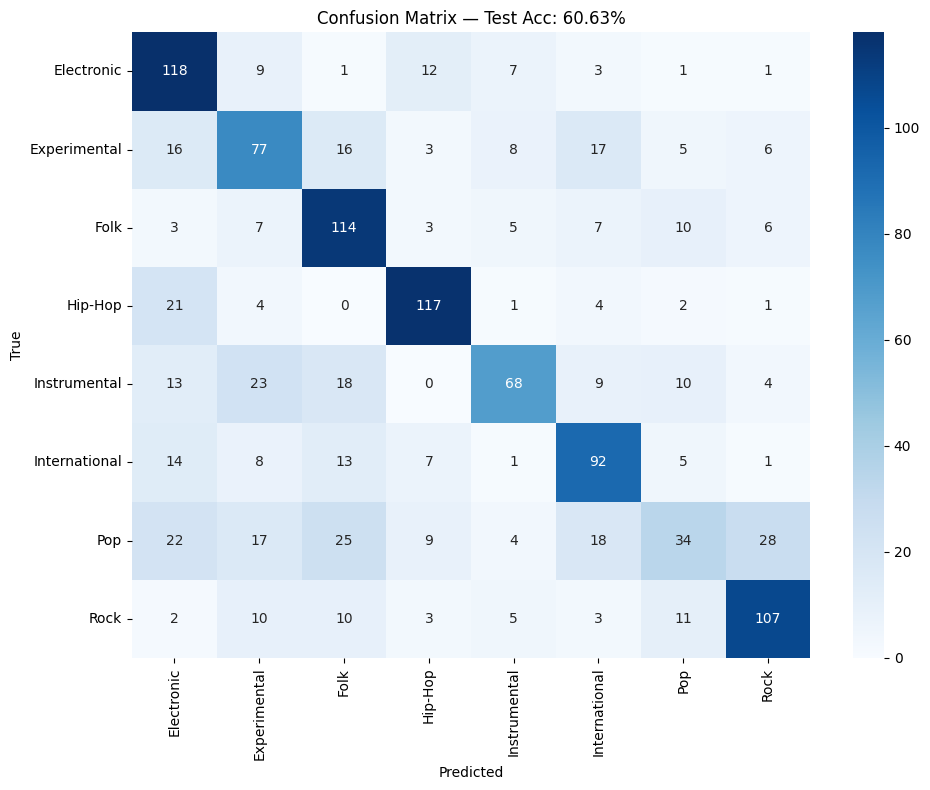

In [18]:
from evaluate import evaluate

# Run evaluation
test_acc = evaluate(config_path="config.yaml", colab=True)


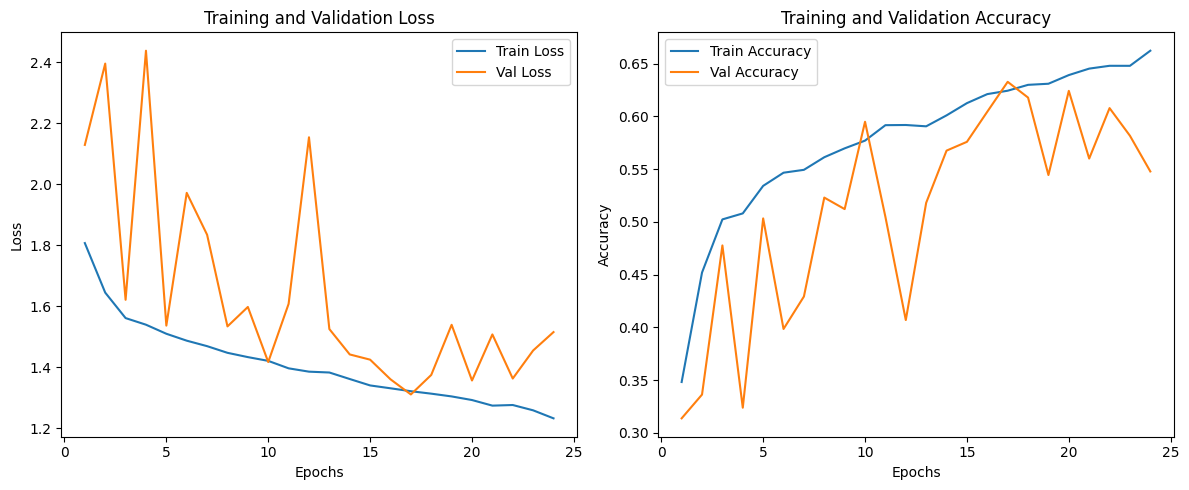

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Accuracy')
plt.plot(epochs, history['val_acc'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
